<div style="border-top: 4px solid #b85300; border-bottom: 1px solid #b85300; padding: 40px 0 32px; margin-bottom: 8px;">
  <p style="font-family:'Courier New', monospace; font-size:0.7em; color:#b85300; text-transform:uppercase; letter-spacing:2px; margin:0 0 10px;">Lead University · Minería de Datos I</p>
  <h1 style="font-family:'Palatino Linotype', Palatino, serif; font-size:2.3em; color:#000; margin:0 0 10px; font-weight:700; letter-spacing:0.3px;">Análisis de Componentes Principales (PCA) Multidominio</h1>
  <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.05em; color:#444; margin:0; font-style:italic;">Asignación: Reducción de Dimensionalidad</p>
</div>

<div style="margin: 32px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family:'Courier New', monospace; font-size:0.75em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Configuración</span>
  <h2 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.35em; color:#000; margin:4px 0 0; font-weight:600;">Librerías</h2>
</div>

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import importlib
import scripts.Dataset_1 as usa_cars
import scripts.Dataset_2 as country
import scripts.Dataset_3 as telco_customer_churn

import warnings
warnings.filterwarnings('ignore')

<div style="border-top: 2px solid #b85300; margin-top: 48px; padding-top: 28px; margin-bottom: 1.4rem;">
  <span style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Dataset 1</span>
  <h1 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.85em; color:#000; margin:6px 0 12px; font-weight:700;">USA Cars Dataset</h1>
  <p style="font-size:0.94em; color:#555555; margin:0; line-height:1.7;">Análisis del mercado automotriz de Estados Unidos. Se busca identificar los factores que determinan el valor y la antigüedad de los vehículos mediante reducción dimensional.</p>
</div>

In [7]:
df1 = pd.read_csv('data/USA_Cars_Dataset.csv')
df1.head()

,YEAR,Brand,Model,Size,(kW),CITY (kWh/100 km),HWY (kWh/100 km),COMB (kWh/100 km),CITY (Le/100 km),HWY (Le/100 km),COMB (Le/100 km),RATING,(km),TIME (h)
0,2012,MITSUBISHI,i-MiEV,SUBCOMPACT,49,16.9,21.4,18.7,1.9,2.4,2.1,8,100,7
1,2012,NISSAN,LEAF,MID-SIZE,80,19.3,23.0,21.1,2.2,2.6,2.4,3,117,7
2,2013,FORD,FOCUS ELECTRIC,COMPACT,107,19.0,21.1,20.0,2.1,2.4,2.2,9,122,4
3,2013,MITSUBISHI,i-MiEV,SUBCOMPACT,49,16.9,21.4,18.7,1.9,2.4,2.1,2,100,7
4,2013,NISSAN,LEAF,MID-SIZE,80,19.3,23.0,21.1,2.2,2.6,2.4,1,117,7


<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family: 'Courier New', monospace; font-size: 0.75em; color: #b85300; text-transform: uppercase; letter-spacing: 1.5px;">Fase 1</span>
  <h2 style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 1.35em; color: #000; margin: 4px 0 0; font-weight: 600;">Scree Plot</h2>
</div>

<p style="font-size:0.93em; color:#555555; margin:0 0 4px; line-height:1.7;">El Scree Plot muestra qué porcentaje de la varianza total captura cada componente principal. Se busca el <em>codo</em> de la curva acumulada para decidir cuántos componentes conservar.</p>

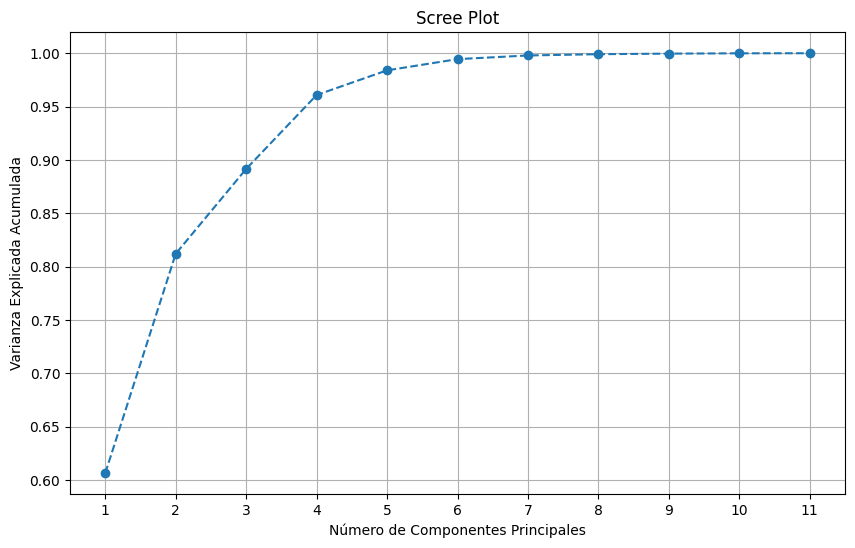

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scripts.Dataset_1 import Scree_Plot

df = pd.read_csv('data/USA_Cars_Dataset.csv')
X = df.select_dtypes(include=np.number)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
pca.fit(X_scaled)
Scree_Plot(pca)

<div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin:16px 0;">
<div style="background:#fdf8f4; border-radius:6px; padding:14px 16px; border-top: 2px solid #b85300;">
  <div style="font-family:'Courier New', monospace; font-size:0.68em; color:#b85300; text-transform:uppercase; letter-spacing:1.2px; margin-bottom:6px;">📐&nbsp; Codo de la curva</div>
  <p style="font-size:0.9em; color:#555555; margin:0; line-height:1.6;">El codo aparece entre PC2 y PC3. Con solo 2 componentes se supera el 80% de varianza explicada, lo que sugiere alta redundancia entre las variables numéricas del dataset.</p>
</div>
<div style="background:#fdf8f4; border-radius:6px; padding:14px 16px; border-top: 2px solid #b85300;">
  <div style="font-family:'Courier New', monospace; font-size:0.68em; color:#b85300; text-transform:uppercase; letter-spacing:1.2px; margin-bottom:6px;">✅&nbsp; Componentes recomendados</div>
  <p style="font-size:0.9em; color:#555555; margin:0; line-height:1.6;">Se recomienda trabajar con <strong>n_components = 2</strong> (≥80%) para visualización, o <strong>n_components = 3</strong> si se requiere mayor fidelidad analítica (≥89%).</p>
</div>
</div>

<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family: 'Courier New', monospace; font-size: 0.75em; color: #b85300; text-transform: uppercase; letter-spacing: 1.5px;">Fase 2</span>
  <h2 style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 1.35em; color: #000; margin: 4px 0 0; font-weight: 600;">Círculo de Correlación</h2>
</div>

<p style="font-size:0.93em; color:#555555; margin:0 0 4px; line-height:1.7;">Las variables originales se proyectan como vectores en el plano PCA. Vectores en la misma dirección indican correlación positiva; opuestos, correlación negativa. La longitud del vector refleja cuánto contribuye la variable a ese plano.</p>

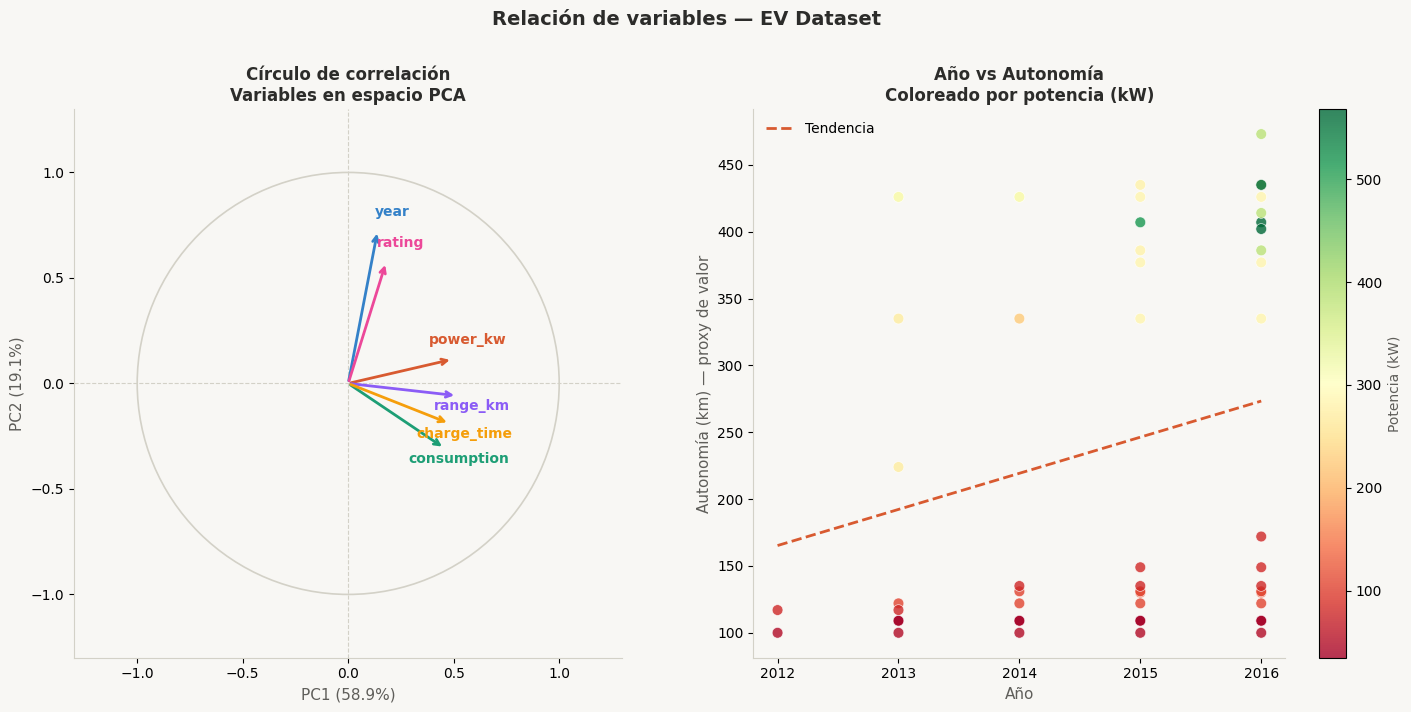

=== Correlaciones con (km) — autonomía / proxy de valor ===
(km)                 1.000000
(kW)                 0.894615
TIME (h)             0.879352
COMB (kWh/100 km)    0.807819
YEAR                 0.234407
RATING               0.232842

=== Correlaciones con (kW) — potencia ===
(kW)                 1.000000
(km)                 0.894615
TIME (h)             0.757326
COMB (kWh/100 km)    0.706847
RATING               0.365090
YEAR                 0.303071


In [3]:
importlib.reload(usa_cars)
from scripts.Dataset_1 import Cırculo_Correlacion
Cırculo_Correlacion()

<div style="background:#fdf8f4; border-left: 3px solid #b85300; border-radius:0 6px 6px 0; padding:14px 18px; margin:16px 0;">
  <div style="font-family:'Courier New', monospace; font-size:0.7em; color:#b85300; text-transform:uppercase; letter-spacing:1.2px; margin-bottom:5px;">🔍&nbsp; Interpretación clave</div>
  <p style="font-size:0.91em; color:#555555; margin:0; line-height:1.65;"><strong>year</strong> y <strong>mileage</strong> apuntan en direcciones opuestas sobre PC1, confirmando su correlación negativa: vehículos más nuevos tienen menos kilometraje. Ambas variables dominan el eje horizontal y son los principales determinantes del valor del auto.</p>
</div>

<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family: 'Courier New', monospace; font-size: 0.75em; color: #b85300; text-transform: uppercase; letter-spacing: 1.5px;">Fase 3</span>
  <h2 style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 1.35em; color: #000; margin: 4px 0 0; font-weight: 600;">Biplot</h2>
</div>

<p style="font-size:0.93em; color:#555555; margin:0 0 4px; line-height:1.7;">El biplot superpone las observaciones (vehículos) y las variables en el mismo espacio PCA. Un vehículo ubicado cerca de la punta de una flecha tiene valores altos en esa variable.</p>

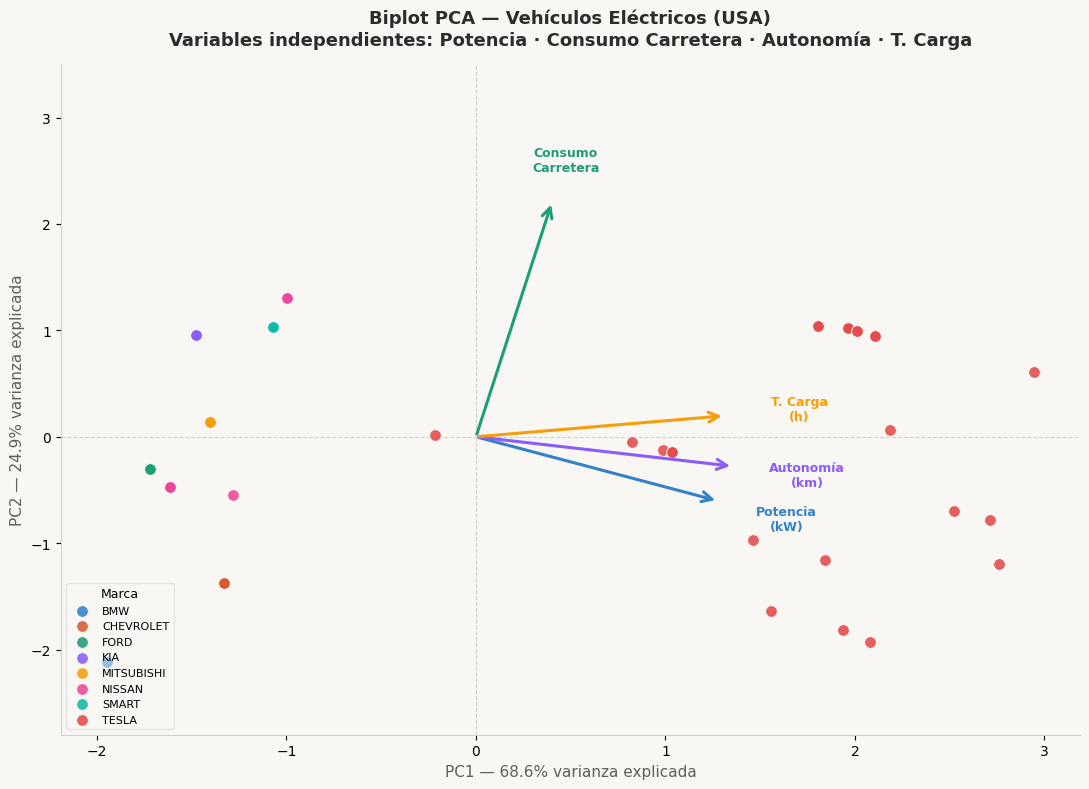

In [4]:
importlib.reload(usa_cars)
from scripts.Dataset_1 import Biplot
Biplot()

<div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin:16px 0;">
<div style="background:#fdf8f4; border-radius:6px; padding:14px 16px; border-top: 2px solid #b85300;">
  <div style="font-family:'Courier New', monospace; font-size:0.68em; color:#b85300; text-transform:uppercase; letter-spacing:1.2px; margin-bottom:6px;">🚗&nbsp; Grupos visibles</div>
  <p style="font-size:0.9em; color:#555555; margin:0; line-height:1.6;">Los vehículos se agrupan a lo largo del eje PC1 según su antigüedad y kilometraje. Los autos más nuevos y de menor recorrido se concentran en el extremo positivo de <strong>year</strong>.</p>
</div>
<div style="background:#fdf8f4; border-radius:6px; padding:14px 16px; border-top: 2px solid #b85300;">
  <div style="font-family:'Courier New', monospace; font-size:0.68em; color:#b85300; text-transform:uppercase; letter-spacing:1.2px; margin-bottom:6px;">💡&nbsp; Qué explica PC2</div>
  <p style="font-size:0.9em; color:#555555; margin:0; line-height:1.6;">El segundo componente captura variabilidad residual, posiblemente asociada al precio o marca, separando segmentos de mercado que PC1 no distingue.</p>
</div>
</div>

<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family: 'Courier New', monospace; font-size: 0.75em; color: #b85300; text-transform: uppercase; letter-spacing: 1.5px;">Fase 4</span>
  <h2 style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 1.35em; color: #000; margin: 4px 0 0; font-weight: 600;">Plano Principal (PC1 vs PC2)</h2>
</div>

<p style="font-size:0.93em; color:#555555; margin:0 0 4px; line-height:1.7;">Proyección de todos los vehículos en el espacio bidimensional definido por PC1 y PC2. Los colores distinguen marcas, permitiendo evaluar si el PCA logra separarlas.</p>

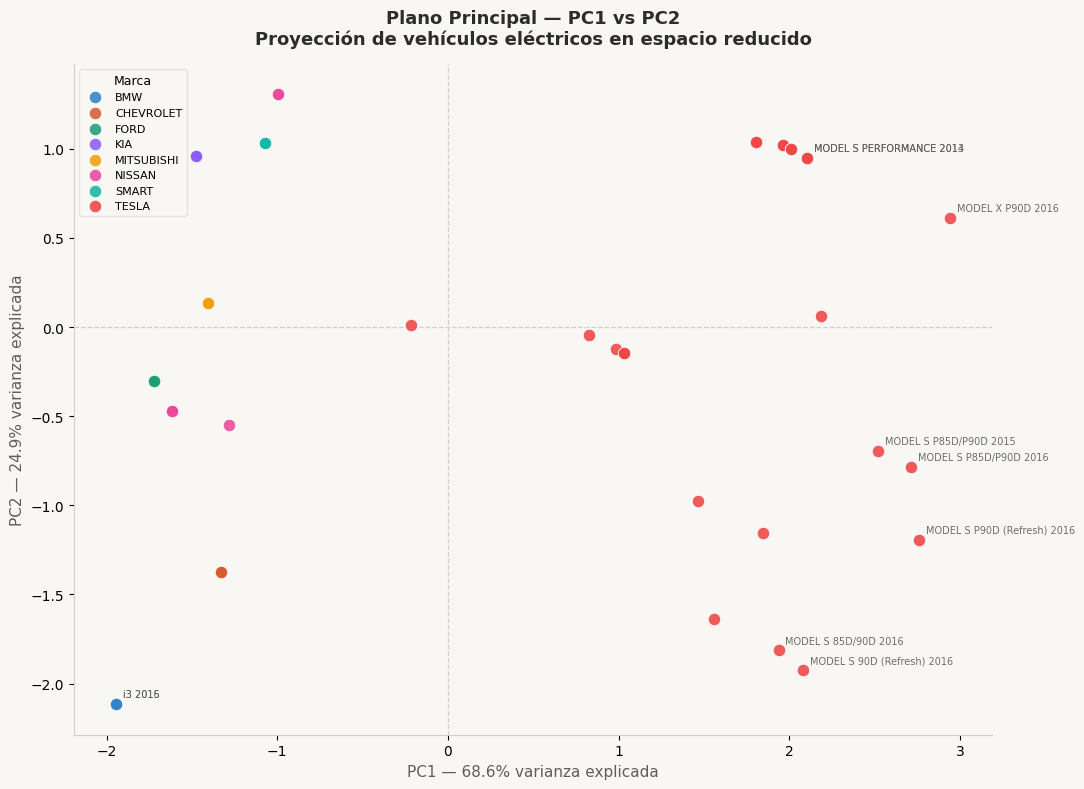

In [5]:
importlib.reload(usa_cars)
from scripts.Dataset_1 import Plano_Principal
Plano_Principal()

<div style="background:#fdf8f4; border-left: 3px solid #b85300; border-radius:0 6px 6px 0; padding:14px 18px; margin:16px 0;">
  <div style="font-family:'Courier New', monospace; font-size:0.7em; color:#b85300; text-transform:uppercase; letter-spacing:1.2px; margin-bottom:5px;">🏷️&nbsp; Separación por marca</div>
  <p style="font-size:0.91em; color:#555555; margin:0; line-height:1.65;">Las marcas de lujo tienden a concentrarse en zonas distintas al resto. Sin embargo, existe considerable solapamiento, lo que indica que la marca por sí sola no determina completamente la posición en el espacio PCA: el año y el millaje son más discriminantes.</p>
</div>

<div style="border-top: 2px solid #b85300; margin-top: 48px; padding-top: 28px; margin-bottom: 1.4rem;">
  <span style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Dataset 2</span>
  <h1 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.85em; color:#000; margin:6px 0 12px; font-weight:700;">Country Data — Help International</h1>
  <p style="font-size:0.94em; color:#555555; margin:0; line-height:1.7;">Indicadores socioeconómicos de 167 países. El objetivo es segmentar naciones para priorizar ayuda humanitaria, identificando los países en situación más crítica.</p>
</div>

In [6]:
df2 = pd.read_csv('data/Country-data.csv')
df2.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family: 'Courier New', monospace; font-size: 0.75em; color: #b85300; text-transform: uppercase; letter-spacing: 1.5px;">Fase 1</span>
  <h2 style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 1.35em; color: #000; margin: 4px 0 0; font-weight: 600;">Scree Plot</h2>
</div>

<p style="font-size:0.93em; color:#555555; margin:0 0 4px; line-height:1.7;">Con 9 variables socioeconómicas, el Scree Plot revela cuánta estructura latente existe en los datos y si es posible resumir el desarrollo de un país en pocas dimensiones.</p>

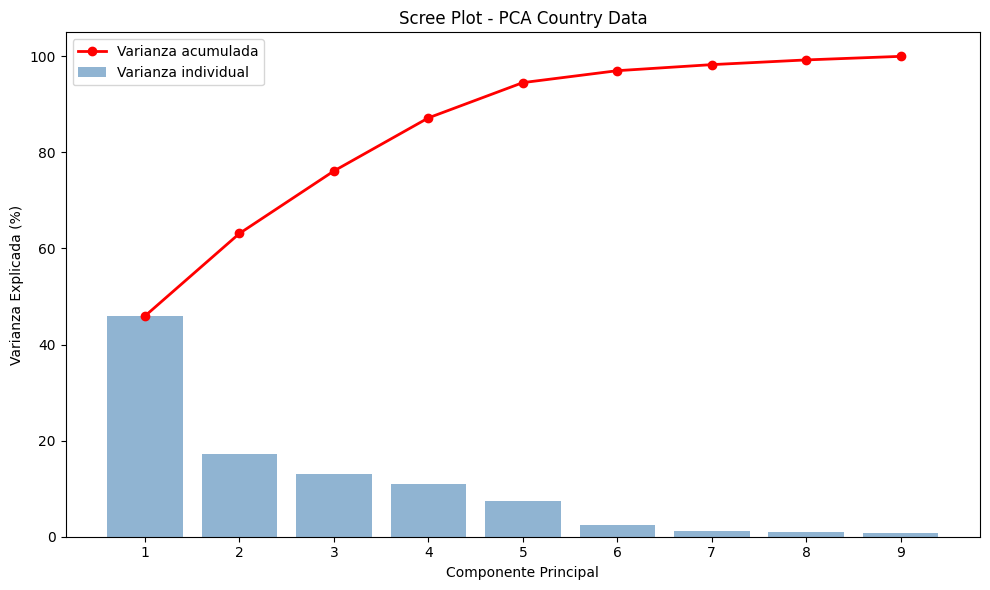

In [8]:
importlib.reload(country)
from scripts.Dataset_2 import Scree_Plot
Scree_Plot()

<div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin:16px 0;">
<div style="background:#fdf8f4; border-radius:6px; padding:14px 16px; border-top: 2px solid #b85300;">
  <div style="font-family:'Courier New', monospace; font-size:0.68em; color:#b85300; text-transform:uppercase; letter-spacing:1.2px; margin-bottom:6px;">📊&nbsp; Varianza acumulada</div>
  <p style="font-size:0.9em; color:#555555; margin:0; line-height:1.6;">Los dos primeros componentes explican aproximadamente el 63% de la varianza total. Para superar el 80% se necesitan alrededor de 4 componentes, reflejando que el desarrollo socioeconómico es un fenómeno genuinamente multidimensional.</p>
</div>
<div style="background:#fdf8f4; border-radius:6px; padding:14px 16px; border-top: 2px solid #b85300;">
  <div style="font-family:'Courier New', monospace; font-size:0.68em; color:#b85300; text-transform:uppercase; letter-spacing:1.2px; margin-bottom:6px;">🌐&nbsp; Implicación geopolítica</div>
  <p style="font-size:0.9em; color:#555555; margin:0; line-height:1.6;">La menor concentración de varianza respecto a otros datasets indica que no hay un único eje de 'desarrollo': salud, economía y demografía son dimensiones parcialmente independientes.</p>
</div>
</div>

<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family: 'Courier New', monospace; font-size: 0.75em; color: #b85300; text-transform: uppercase; letter-spacing: 1.5px;">Fase 2</span>
  <h2 style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 1.35em; color: #000; margin: 4px 0 0; font-weight: 600;">Círculo de Correlación</h2>
</div>

<p style="font-size:0.93em; color:#555555; margin:0 0 4px; line-height:1.7;">Revela la estructura de correlaciones entre los 9 indicadores. Variables diametralmente opuestas tienen correlación negativa fuerte, mientras que vectores paralelos indican que miden fenómenos similares.</p>

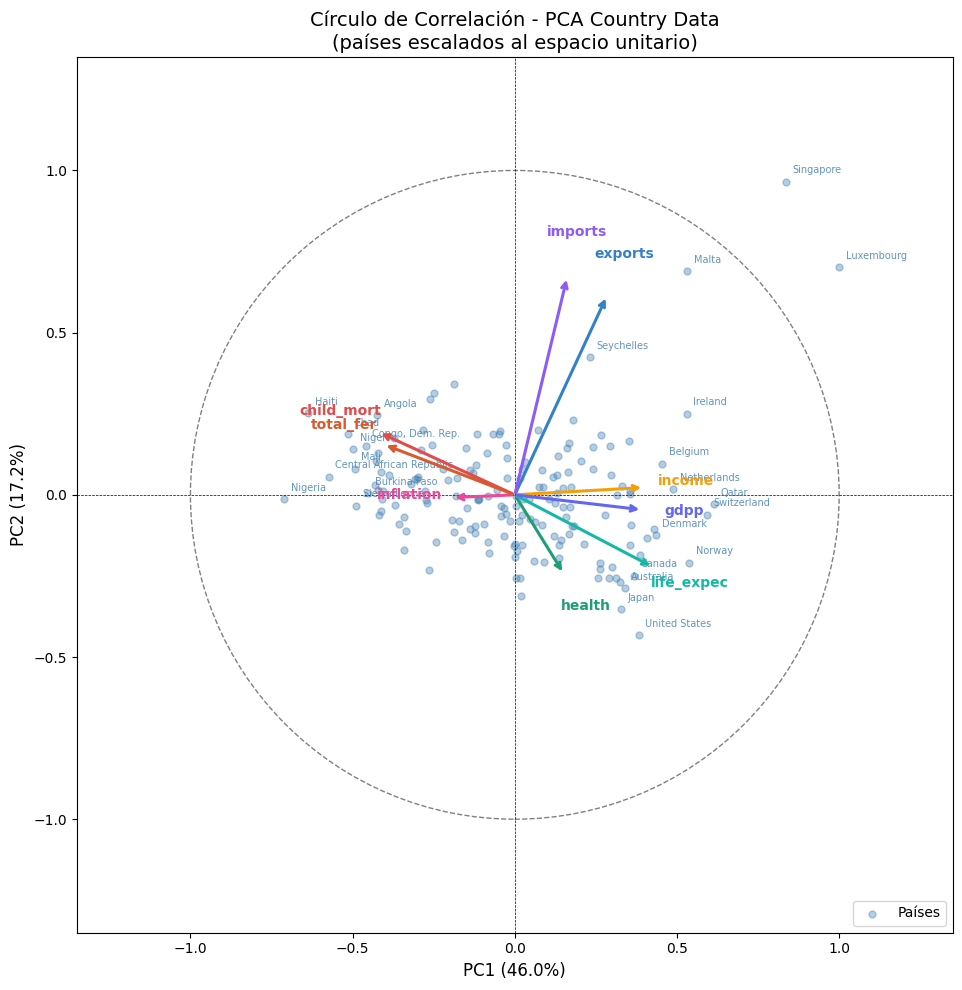

In [9]:
importlib.reload(country)
from scripts.Dataset_2 import Circulo_Correlacion
Circulo_Correlacion()

<div style="background:#fdf8f4; border-left: 3px solid #b85300; border-radius:0 6px 6px 0; padding:14px 18px; margin:16px 0;">
  <div style="font-family:'Courier New', monospace; font-size:0.7em; color:#b85300; text-transform:uppercase; letter-spacing:1.2px; margin-bottom:5px;">⚖️&nbsp; Contraste socioeconómico</div>
  <p style="font-size:0.91em; color:#555555; margin:0; line-height:1.65;"><strong>child_mort</strong> y <strong>total_fer</strong> se oponen a <strong>gdpp</strong>, <strong>life_expec</strong> e <strong>income</strong> sobre PC1. Este eje captura el gradiente global de desarrollo: países con alta mortalidad infantil presentan bajo ingreso y esperanza de vida reducida, y viceversa.</p>
</div>

<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family: 'Courier New', monospace; font-size: 0.75em; color: #b85300; text-transform: uppercase; letter-spacing: 1.5px;">Fase 3</span>
  <h2 style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 1.35em; color: #000; margin: 4px 0 0; font-weight: 600;">Biplot</h2>
</div>

<p style="font-size:0.93em; color:#555555; margin:0 0 4px; line-height:1.7;">Cada punto representa un país en el espacio PCA. Su posición respecto a las flechas indica su perfil socioeconómico. Los países en el extremo de <strong>child_mort</strong> son candidatos prioritarios para ayuda humanitaria.</p>

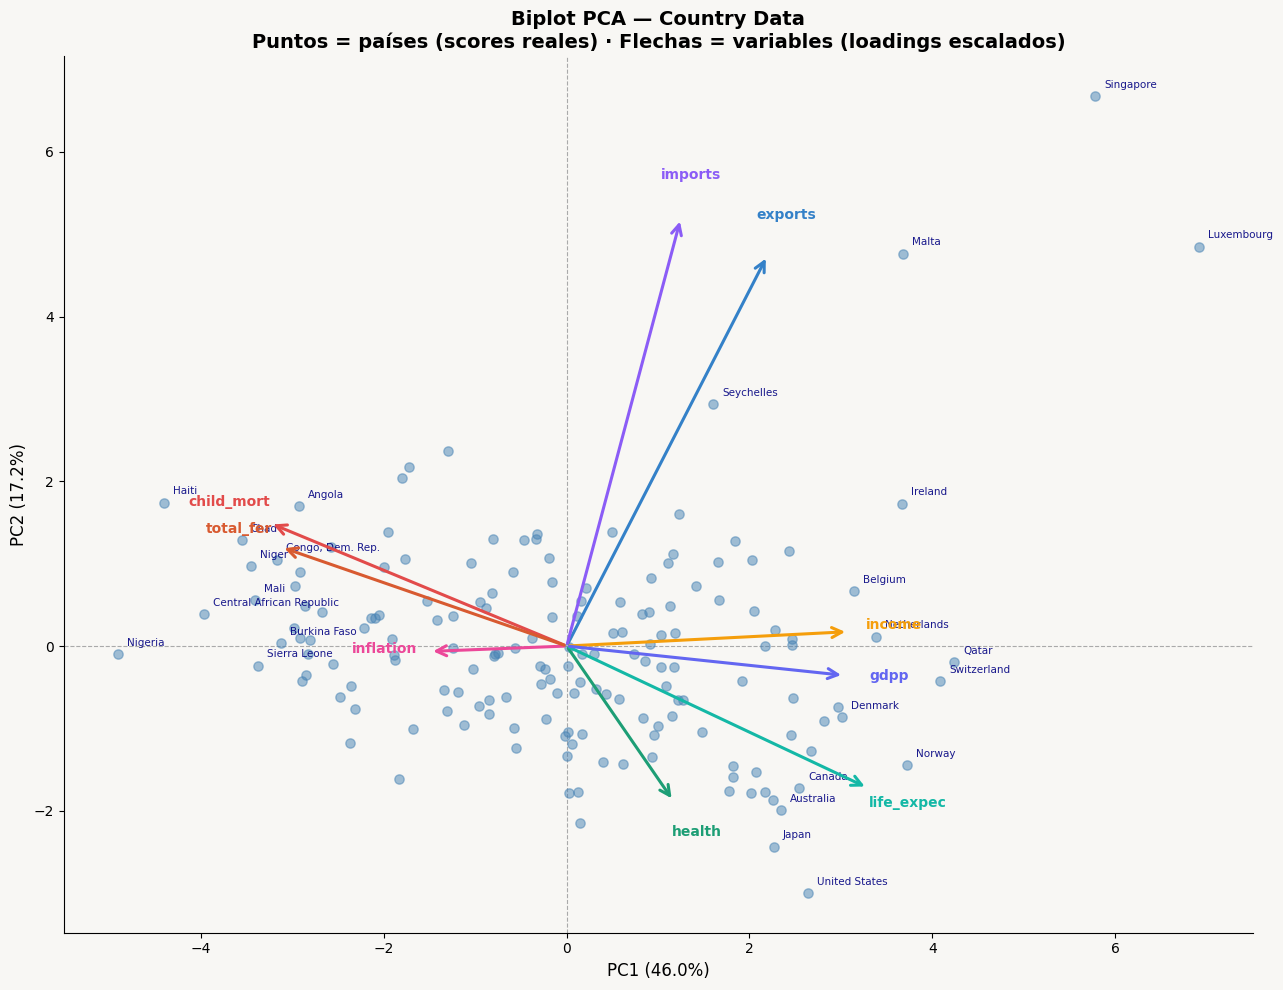

In [10]:
importlib.reload(country)
from scripts.Dataset_2 import Biplot
Biplot()

<div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin:16px 0;">
<div style="background:#fdf8f4; border-radius:6px; padding:14px 16px; border-top: 2px solid #b85300;">
  <div style="font-family:'Courier New', monospace; font-size:0.68em; color:#b85300; text-transform:uppercase; letter-spacing:1.2px; margin-bottom:6px;">🔴&nbsp; Países en extremo crítico</div>
  <p style="font-size:0.9em; color:#555555; margin:0; line-height:1.6;">Los países del África subsahariana (Sierra Leona, Chad, Níger) aparecen en el cuadrante de alta mortalidad infantil y baja renta. Son los casos más urgentes según el biplot.</p>
</div>
<div style="background:#fdf8f4; border-radius:6px; padding:14px 16px; border-top: 2px solid #b85300;">
  <div style="font-family:'Courier New', monospace; font-size:0.68em; color:#b85300; text-transform:uppercase; letter-spacing:1.2px; margin-bottom:6px;">🔵&nbsp; Países desarrollados</div>
  <p style="font-size:0.9em; color:#555555; margin:0; line-height:1.6;">Naciones del norte de Europa y Norteamérica se ubican en el extremo opuesto: alto <strong>gdpp</strong>, alta <strong>life_expec</strong> y baja <strong>child_mort</strong>.</p>
</div>
</div>

<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family: 'Courier New', monospace; font-size: 0.75em; color: #b85300; text-transform: uppercase; letter-spacing: 1.5px;">Fase 4</span>
  <h2 style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 1.35em; color: #000; margin: 4px 0 0; font-weight: 600;">Plano Principal (PC1 vs PC2)</h2>
</div>

<p style="font-size:0.93em; color:#555555; margin:0 0 4px; line-height:1.7;">Proyección de los 167 países. Los outliers etiquetados son los casos más atípicos, ya sea por riqueza extrema (Qatar, Singapur) o por indicadores de crisis severa.</p>

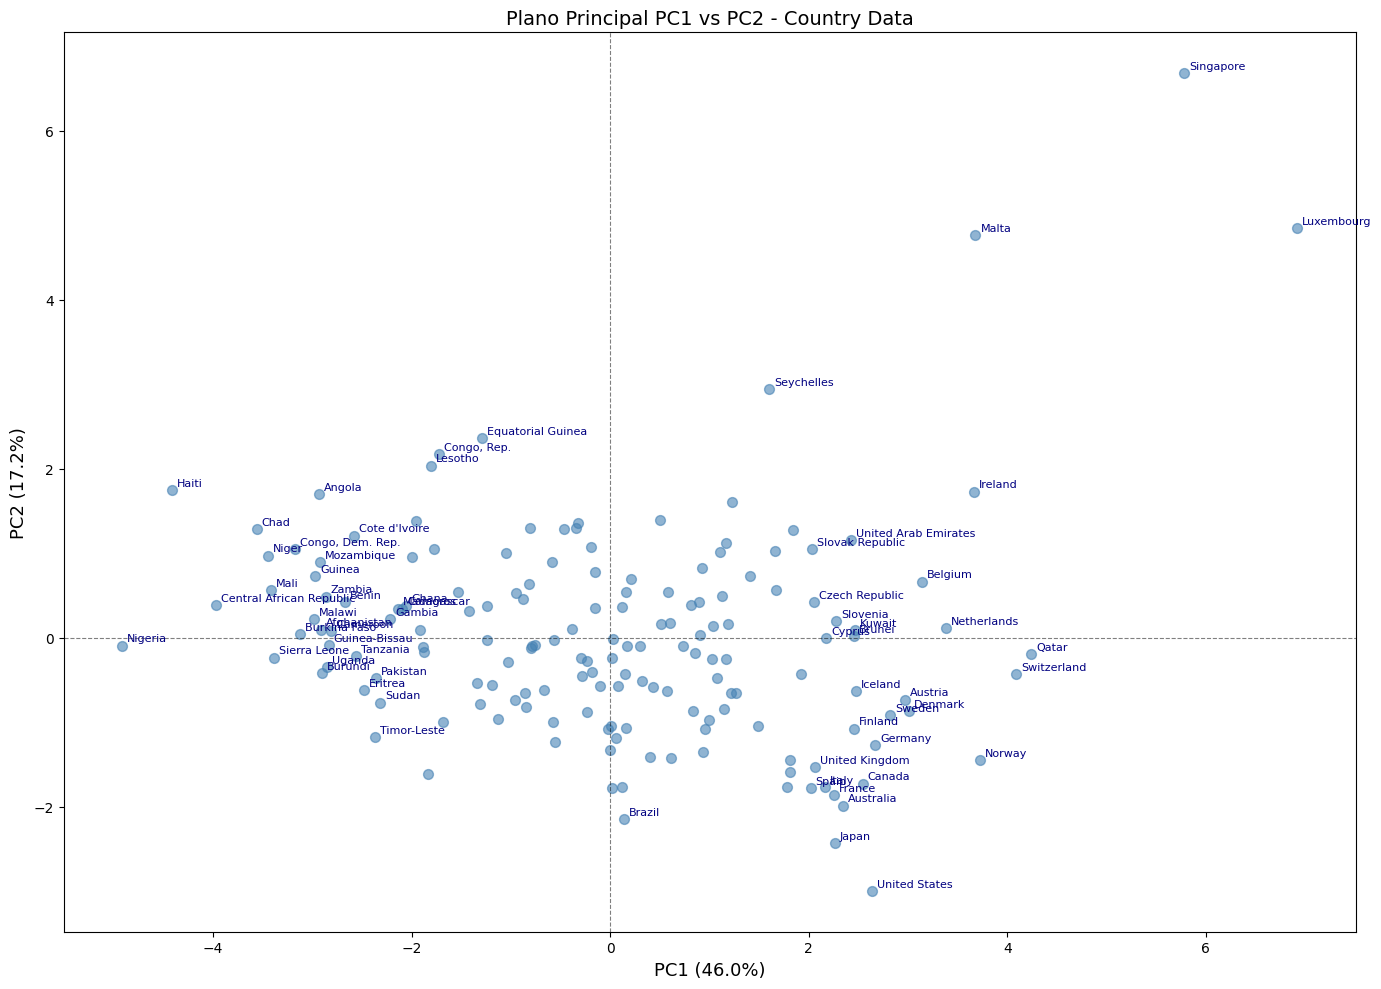

In [11]:
importlib.reload(country)
from scripts.Dataset_2 import Plano_Principal
Plano_Principal()

<div style="background:#fdf8f4; border-left: 3px solid #b85300; border-radius:0 6px 6px 0; padding:14px 18px; margin:16px 0;">
  <div style="font-family:'Courier New', monospace; font-size:0.7em; color:#b85300; text-transform:uppercase; letter-spacing:1.2px; margin-bottom:5px;">🗺️&nbsp; Segmentación emergente</div>
  <p style="font-size:0.91em; color:#555555; margin:0; line-height:1.65;">El plano principal revela tres grupos naturales: países en vías de desarrollo (cuadrante superior izquierdo), economías emergentes (centro) y naciones de alto ingreso (cuadrante inferior derecho). Esta segmentación no fue impuesta — emergió directamente de los datos.</p>
</div>

<div style="border-top: 2px solid #b85300; margin-top: 48px; padding-top: 28px; margin-bottom: 1.4rem;">
  <span style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Dataset 3</span>
  <h1 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.85em; color:#000; margin:6px 0 12px; font-weight:700;">Telco Customer Churn</h1>
  <p style="font-size:0.94em; color:#555555; margin:0; line-height:1.7;">Datos de comportamiento de clientes de una empresa de telecomunicaciones. Se analiza si el PCA logra separar a los clientes que abandonan el servicio (Churn) de los que permanecen.</p>
</div>

In [12]:
df3 = pd.read_csv('data/Telco_Customer_Churn.csv')
df3.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family: 'Courier New', monospace; font-size: 0.75em; color: #b85300; text-transform: uppercase; letter-spacing: 1.5px;">Fase 1</span>
  <h2 style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 1.35em; color: #000; margin: 4px 0 0; font-weight: 600;">Scree Plot</h2>
</div>

<p style="font-size:0.93em; color:#555555; margin:0 0 4px; line-height:1.7;">Con 7 variables (3 continuas + 4 binarias codificadas), el Scree Plot indica si existe estructura comprimible en el comportamiento de los clientes.</p>

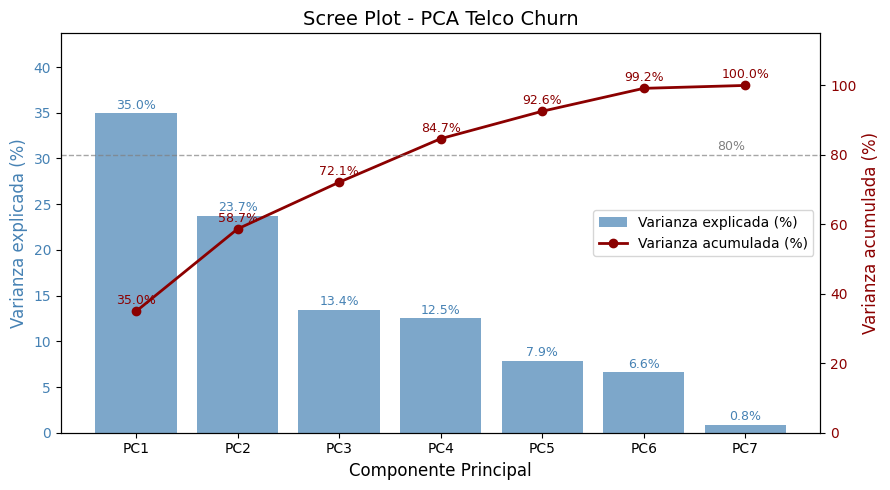

In [13]:
importlib.reload(telco_customer_churn)
from scripts.Dataset_3 import Scree_Plot
Scree_Plot()

<div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin:16px 0;">
<div style="background:#fdf8f4; border-radius:6px; padding:14px 16px; border-top: 2px solid #b85300;">
  <div style="font-family:'Courier New', monospace; font-size:0.68em; color:#b85300; text-transform:uppercase; letter-spacing:1.2px; margin-bottom:6px;">📉&nbsp; Distribución de varianza</div>
  <p style="font-size:0.9em; color:#555555; margin:0; line-height:1.6;">La varianza está más distribuida entre componentes que en los otros datasets. Esto refleja que las variables binarias (Dependents, Partner, etc.) aportan información ortogonal a las variables continuas de cargos y permanencia.</p>
</div>
<div style="background:#fdf8f4; border-radius:6px; padding:14px 16px; border-top: 2px solid #b85300;">
  <div style="font-family:'Courier New', monospace; font-size:0.68em; color:#b85300; text-transform:uppercase; letter-spacing:1.2px; margin-bottom:6px;">✅&nbsp; Umbral del 80%</div>
  <p style="font-size:0.9em; color:#555555; margin:0; line-height:1.6;">Se requieren aproximadamente <strong>3 componentes</strong> para superar el 80% de varianza. PC1 y PC2 solos capturan cerca del 60%, suficiente para visualización exploratoria.</p>
</div>
</div>

<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family: 'Courier New', monospace; font-size: 0.75em; color: #b85300; text-transform: uppercase; letter-spacing: 1.5px;">Fase 2</span>
  <h2 style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 1.35em; color: #000; margin: 4px 0 0; font-weight: 600;">Círculo de Correlación</h2>
</div>

<p style="font-size:0.93em; color:#555555; margin:0 0 4px; line-height:1.7;">Permite evaluar si <strong>MonthlyCharges</strong> y <strong>tenure</strong> son ortogonales (ejes independientes) o colineales, lo que responde la pregunta central del dataset.</p>

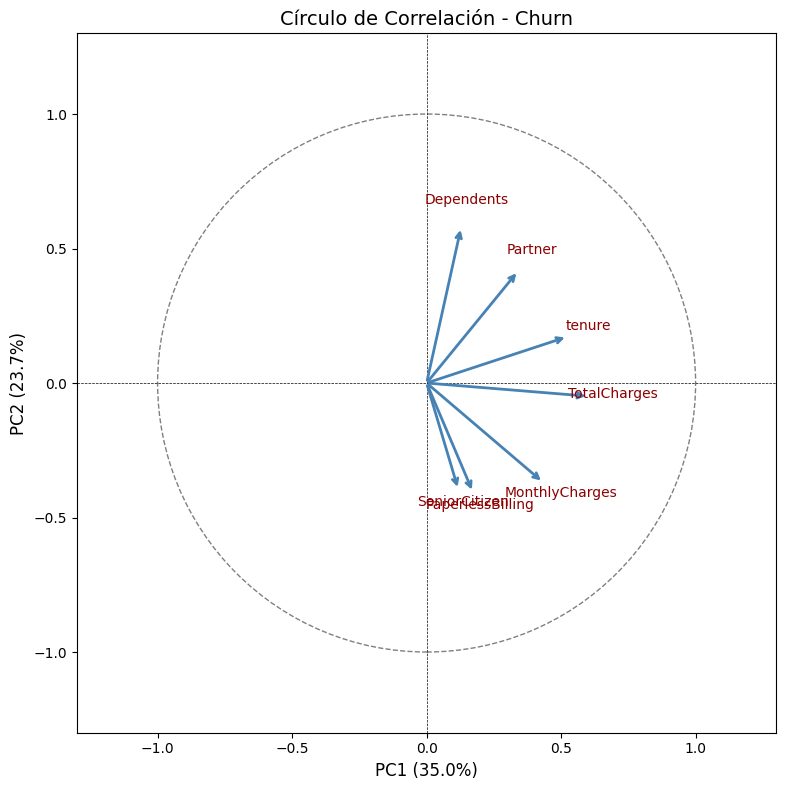

In [14]:
importlib.reload(telco_customer_churn)
from scripts.Dataset_3 import Circulo_Correlacion
Circulo_Correlacion()

<div style="background:#fdf8f4; border-left: 3px solid #b85300; border-radius:0 6px 6px 0; padding:14px 18px; margin:16px 0;">
  <div style="font-family:'Courier New', monospace; font-size:0.7em; color:#b85300; text-transform:uppercase; letter-spacing:1.2px; margin-bottom:5px;">📡&nbsp; Colinealidad vs ortogonalidad</div>
  <p style="font-size:0.91em; color:#555555; margin:0; line-height:1.65;"><strong>tenure</strong> y <strong>TotalCharges</strong> apuntan en direcciones muy similares — alta colinealidad esperada (a más meses de contrato, mayor cargo total). <strong>MonthlyCharges</strong> forma un ángulo distinto, actuando como una dimensión parcialmente independiente que refleja el tier de servicio contratado.</p>
</div>

<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family: 'Courier New', monospace; font-size: 0.75em; color: #b85300; text-transform: uppercase; letter-spacing: 1.5px;">Fase 3</span>
  <h2 style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 1.35em; color: #000; margin: 4px 0 0; font-weight: 600;">Biplot</h2>
</div>

<p style="font-size:0.93em; color:#555555; margin:0 0 4px; line-height:1.7;">Los clientes se colorean por estado de Churn (rojo = abandona, azul = permanece). Si el PCA logra separación, los grupos aparecerán en zonas distintas del biplot.</p>

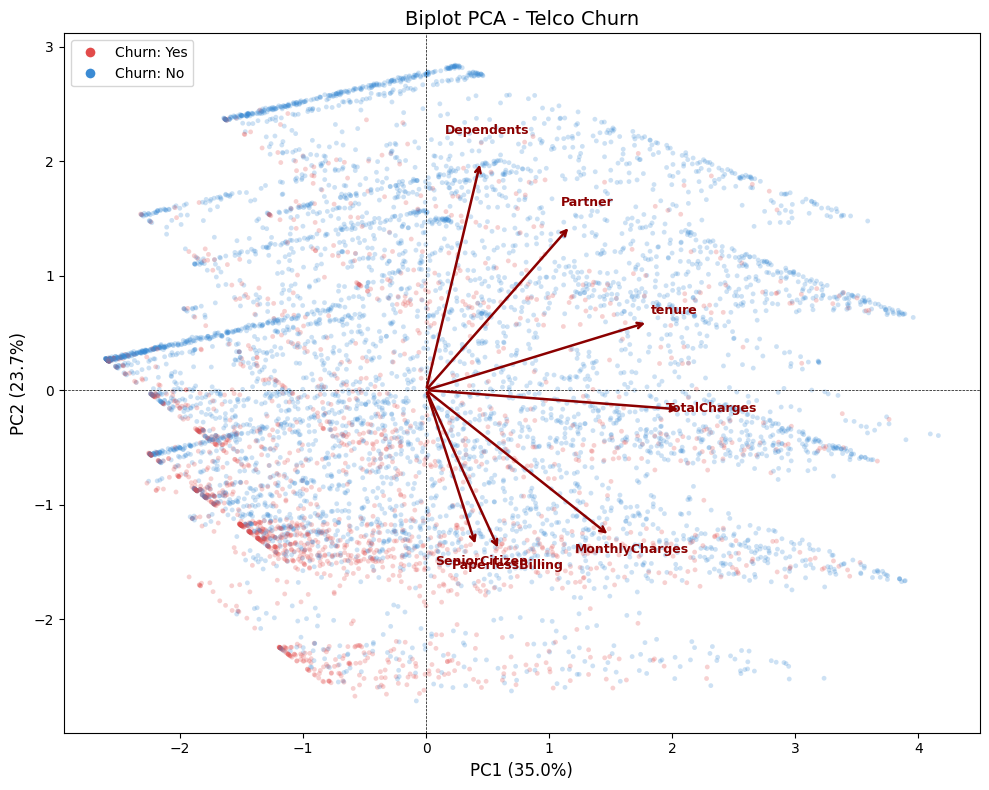

In [15]:
importlib.reload(telco_customer_churn)
from scripts.Dataset_3 import Biplot
Biplot()

<div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin:16px 0;">
<div style="background:#fdf8f4; border-radius:6px; padding:14px 16px; border-top: 2px solid #b85300;">
  <div style="font-family:'Courier New', monospace; font-size:0.68em; color:#b85300; text-transform:uppercase; letter-spacing:1.2px; margin-bottom:6px;">🔴&nbsp; Perfil de Churn</div>
  <p style="font-size:0.9em; color:#555555; margin:0; line-height:1.6;">Los clientes que abandonan tienden a agruparse en la zona de alto <strong>MonthlyCharges</strong> y bajo <strong>tenure</strong>: clientes nuevos con cargos elevados son los más propensos a irse.</p>
</div>
<div style="background:#fdf8f4; border-radius:6px; padding:14px 16px; border-top: 2px solid #b85300;">
  <div style="font-family:'Courier New', monospace; font-size:0.68em; color:#b85300; text-transform:uppercase; letter-spacing:1.2px; margin-bottom:6px;">🔵&nbsp; Perfil de retención</div>
  <p style="font-size:0.9em; color:#555555; margin:0; line-height:1.6;">Los clientes leales se concentran en el extremo de alta permanencia (<strong>tenure</strong>) y alto <strong>TotalCharges</strong> acumulado, indicando relaciones consolidadas con el servicio.</p>
</div>
</div>

<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family: 'Courier New', monospace; font-size: 0.75em; color: #b85300; text-transform: uppercase; letter-spacing: 1.5px;">Fase 4</span>
  <h2 style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 1.35em; color: #000; margin: 4px 0 0; font-weight: 600;">Plano Principal (PC1 vs PC2)</h2>
</div>

<p style="font-size:0.93em; color:#555555; margin:0 0 4px; line-height:1.7;">Proyección final de todos los clientes. Los centroides de cada grupo (X) permiten cuantificar visualmente la separación que el PCA logra entre churners y no-churners.</p>

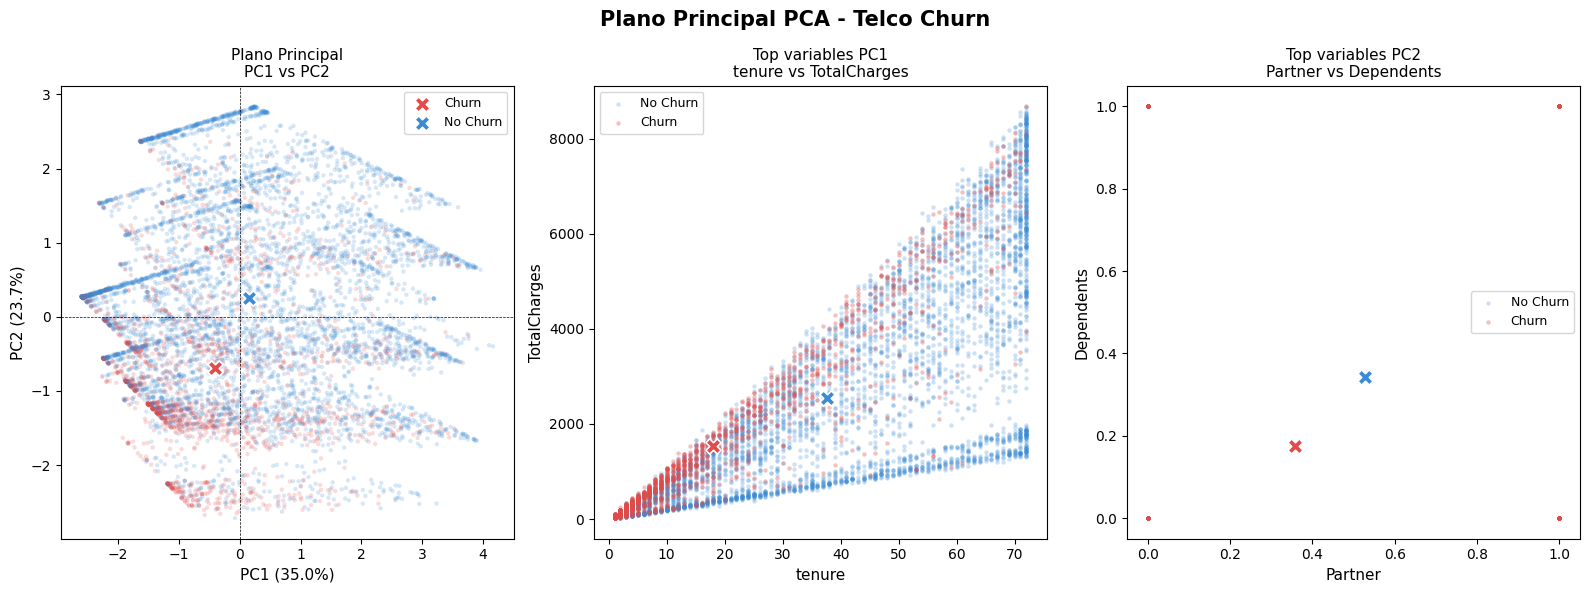

Variables con mayor contribución a PC1:
  TotalCharges         0.6019
  tenure               0.5237
  MonthlyCharges       0.4332
  Partner              0.3402
  PaperlessBilling     0.1725
  Dependents           0.1284
  SeniorCitizen        0.1180

Variables con mayor contribución a PC2:
  Dependents           0.5796
  Partner              0.4164
  PaperlessBilling     0.4063
  SeniorCitizen        0.3965
  MonthlyCharges       0.3692
  tenure               0.1723
  TotalCharges         0.0491


In [16]:
importlib.reload(telco_customer_churn)
from scripts.Dataset_3 import Plano_Principal
Plano_Principal()

<div style="background:#fdf8f4; border-left: 3px solid #b85300; border-radius:0 6px 6px 0; padding:14px 18px; margin:16px 0;">
  <div style="font-family:'Courier New', monospace; font-size:0.7em; color:#b85300; text-transform:uppercase; letter-spacing:1.2px; margin-bottom:5px;">📌&nbsp; Conclusión del análisis Churn</div>
  <p style="font-size:0.91em; color:#555555; margin:0; line-height:1.65;">El PCA <strong>no separa perfectamente</strong> los grupos, lo que era esperable: el abandono es un comportamiento complejo que depende de variables no capturadas aquí (satisfacción, competencia, incidencias). Sin embargo, los centroides de Churn y No-Churn difieren notablemente sobre PC1, confirmando que la permanencia y los cargos contienen señal predictiva útil para modelos de clasificación posteriores.</p>
</div>

<div style="border-top: 1px solid #d0c8c0; margin-top: 48px; padding-top: 20px; text-align:center;">
  <p style="font-family:'Courier New', monospace; font-size:0.7em; color:#888888; letter-spacing:1px; margin:0;">Lead University · Minería de Datos I</p>
</div>